In [1]:
DATASET_FOLDER='../dataset'

In [3]:
import os
import random

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

import torch

from ultralytics import YOLO

In [4]:
model = YOLO('yolov8n.pt')

In [5]:
res = model.predict(
   source='https://media.roboflow.com/notebooks/examples/dog.jpeg',
   conf=0.25
)


Found https://media.roboflow.com/notebooks/examples/dog.jpeg locally at dog.jpeg
image 1/1 /home/harhaleval/courses/cv/object_detection/dog.jpeg: 640x384 1 person, 1 car, 1 dog, 63.3ms
Speed: 2.9ms preprocess, 63.3ms inference, 158.2ms postprocess per image at shape (1, 3, 640, 384)


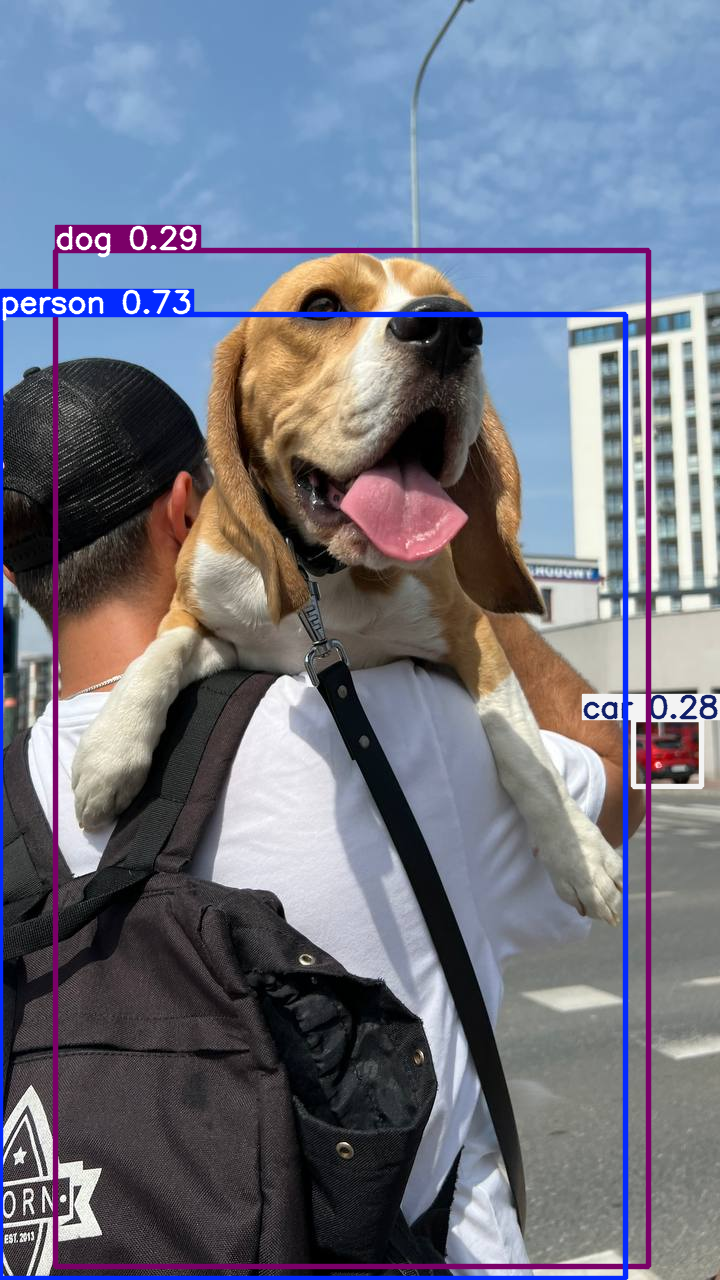

In [6]:
res[0].show()

In [11]:
images = os.listdir(os.path.join(DATASET_FOLDER, 'train', 'images'))
rand_img = random.choice(images)
rand_lbs = rand_img.split('.')[0] + '.txt'

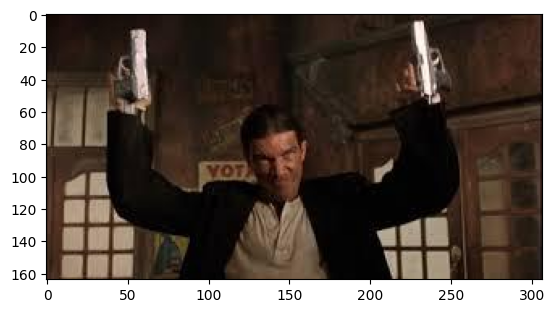

In [12]:
image = cv2.imread(os.path.join(DATASET_FOLDER, 'train', 'images', rand_img))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()

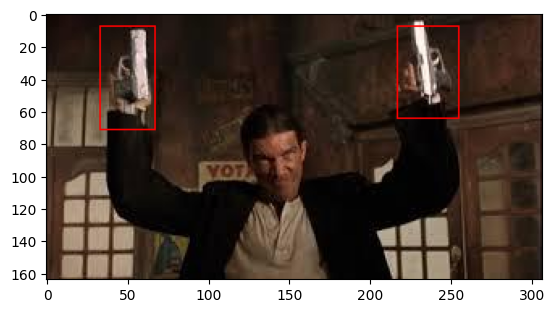

In [13]:
with open(os.path.join(DATASET_FOLDER, 'train', 'labels', rand_lbs)) as f:
    lines = f.readlines()
    color = (255, 0, 0)
    for bbox in lines:
        cls, xc, yc, w, h = map(float, bbox.split())
        img_h, img_w = image.shape[:2]
        x1 = int((xc - w/2) * img_w)
        y1 = int((yc - h/2) * img_h)
        x2 = int((xc + w/2) * img_w)
        y2 = int((yc + h/2) * img_h)
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 1)
plt.imshow(image)
plt.show()

In [14]:
TRAIN_FOLDER = os.path.join(DATASET_FOLDER, 'train')
TEST_FOLDER = os.path.join(DATASET_FOLDER, 'test')

In [15]:
with open('data.yaml','w') as f:
    data = f"train: {TRAIN_FOLDER}\nval: {TEST_FOLDER}\nnc: 1\nnames: [\n'gun'\n]"
    f.write(data)
    f.close()

In [16]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
model = YOLO("yolov8n.pt") 

results = model.train(
    data="data.yaml",
    epochs=110,
    imgsz=1280,
    batch=32,
    name="guns_training"
)


In [27]:
model = YOLO("runs/detect/guns_training/weights/best.pt")

In [ ]:
metrics = model.val()

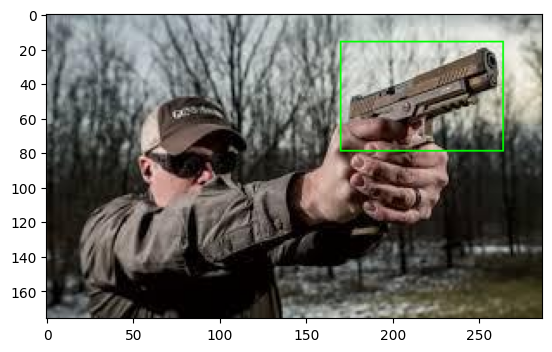


image 1/1 /home/harhaleval/courses/cv/object_detection/yolo/dataset/test/images/163.jpeg: 800x1280 1 gun, 6.0ms
Speed: 7.0ms preprocess, 6.0ms inference, 1.2ms postprocess per image at shape (1, 3, 800, 1280)
Results saved to results/res12


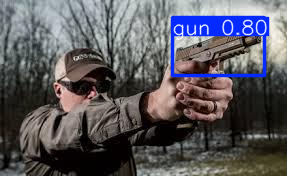

In [92]:
test_images = os.listdir(os.path.join(TEST_FOLDER, 'images'))
rand_img = np.random.choice(test_images)
rand_lb = rand_img.split('.')[0] + '.txt'
with open(os.path.join(TEST_FOLDER, 'labels', rand_lb)) as f:
    bboxes = f.readlines()
image = cv2.imread(os.path.join(TEST_FOLDER, 'images', rand_img))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
h, w, c = image.shape
for bbox in bboxes:
    class_id, xc, yc, bb_w, bb_h = map(float, bbox.split())
    x1, y1 = (xc - bb_w / 2) * w, (yc - bb_h / 2) * h
    x2, y2 = (xc + bb_w / 2) * w, (yc + bb_h / 2) * h
    x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 1)
plt.imshow(image)
plt.show()

res = model.predict(
   source=os.path.join(TEST_FOLDER, 'images', rand_img),
    save=True,
    project='./results'
)

res[0].show()

In [78]:
os.getcwd()

'/home/harhaleval/courses/cv/object_detection/yolo'

In [81]:
res = model.predict(
   source=os.path.join(TEST_FOLDER, 'images', rand_img),
    save=True,
    project='./results'
)


image 1/1 /home/harhaleval/courses/cv/object_detection/yolo/dataset/test/images/21.jpeg: 960x1280 1 gun, 10.5ms
Speed: 13.5ms preprocess, 10.5ms inference, 2.3ms postprocess per image at shape (1, 3, 960, 1280)
Results saved to results/res


In [74]:
res[0]

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'gun'}
obb: None
orig_img: array([[[ 32,  33,  31],
        [ 31,  32,  30],
        [ 30,  31,  29],
        ...,
        [139, 147, 146],
        [139, 147, 146],
        [139, 147, 146]],

       [[ 37,  38,  36],
        [ 36,  37,  35],
        [ 34,  35,  33],
        ...,
        [139, 147, 146],
        [139, 147, 146],
        [139, 147, 146]],

       [[ 35,  36,  34],
        [ 32,  33,  31],
        [ 27,  28,  26],
        ...,
        [139, 147, 146],
        [139, 147, 146],
        [139, 147, 146]],

       ...,

       [[154, 160, 155],
        [154, 160, 155],
        [154, 160, 155],
        ...,
        [118, 127, 124],
        [118, 127, 124],
        [118, 127, 124]],

       [[154, 160, 155],
        [154, 160, 155],
        [154, 160, 155],
        ...,
        [118, 127, 124],
        [117, 126, 123],
        [117, 12